# 公式テスト t1 — Birth-Death

> **出典（E-Cell4 公式）**: Tests / Birth-Death — https://ecell4.e-cell.org/tests/Birth_Death.html
>
> E-Cell4 公式の**テストモデル**（各ソルバが同じ答えに収束するかの検証用）。生成 `∅→A` と死滅 `A→∅` だけの最小系。
> ここでは ODE と Gillespie を実行。空間ソルバ（meso/spatiocyte/egfrd/bd）の公式呼び出しは末尾に参照掲載（重い）。

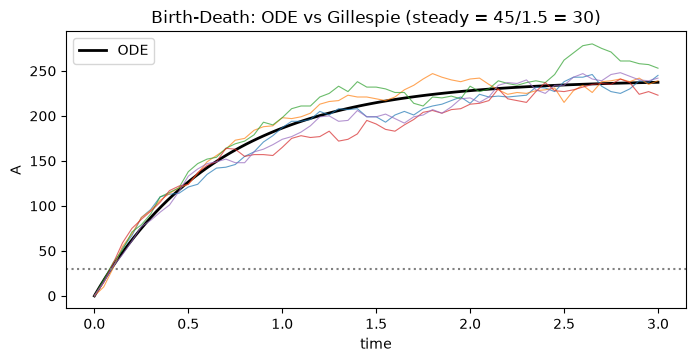

In [1]:
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from ecell4.prelude import *

D, radius, V, duration = 1, 0.005, 8, 3
with species_attributes():
    A | {'radius': radius, 'D': D}
with reaction_rules():
    ~A > A | 45.0   # birth
    A > ~A | 1.5    # death
m = get_model()

a = run_simulation(duration, y0={}, volume=V, model=m, species_list=['A']).as_array()
plt.figure(figsize=(8,3.6))
plt.plot(a[:,0], a[:,1], 'k-', lw=2, label='ODE')
for seed in range(5):
    g = run_simulation(duration, y0={}, volume=V, model=m, solver='gillespie', ndiv=60, species_list=['A'], rndseed=seed).as_array()
    plt.plot(g[:,0], g[:,1], lw=.8, alpha=.7)
plt.axhline(30, ls=':', c='gray'); plt.xlabel('time'); plt.ylabel('A'); plt.legend(); plt.title('Birth-Death: ODE vs Gillespie (steady = 45/1.5 = 30)'); plt.show()

## 全ソルバ比較（公式コード・参照）

公式テストは同じモデルを**全ソルバ**で回して一致を確認する（空間系は重いのでここでは非実行）:

```python
ret2 = ensemble_simulations(duration, ndiv=20, y0={}, volume=V, model=m, solver='gillespie', repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0={}, volume=V, model=m, solver=('meso', Integer3(3,3,3), 0.25), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0={}, volume=V, model=m, solver=('spatiocyte', radius), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0={}, volume=V, model=m, solver=('egfrd', Integer3(8,8,8)), repeat=20)
ret2 = ensemble_simulations(duration, ndiv=20, y0={}, volume=V, model=m, solver=('bd', Integer3(8,8,8), 0.1), repeat=20)
```

**要点**: 生成・死滅のみの系は定常 `birth/death = 30` に収束。全ソルバがこの平均に一致する（well-mixed から単分子空間まで）——E-Cell4 のマルチアルゴリズムの整合性テスト。